# Importing the data

In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder


df = pd.read_excel('/content/student_data_final.xlsx')

print("Sample of data:\n", df.head())

Sample of data:
   assessment_type  weight  date_submitted  score  date_registration gender  \
0             TMA    10.0              18     78             -159.0      M   
1             TMA    10.0              22     70              -53.0      F   
2             TMA    10.0              17     72              -52.0      F   
3             TMA    10.0              26     69             -176.0      F   
4             TMA    10.0              19     79             -110.0      M   

                 region      highest_education imd_band age_band  \
0   East Anglian Region       HE Qualification  90-100%     55<=   
1              Scotland       HE Qualification   20-30%    35-55   
2     South East Region  A Level or Equivalent   50-60%    35-55   
3  West Midlands Region     Lower Than A Level   50-60%     0-35   
4                 Wales  A Level or Equivalent   80-90%    35-55   

   num_of_prev_attempts  studied_credits disability  \
0                     0              240          

In [2]:

column_names = df.columns.tolist()

print(column_names)

['assessment_type', 'weight', 'date_submitted', 'score', 'date_registration', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'module_presentation_length', 'final_result']


# Encoding of data

In [3]:

df1=df.copy()

categorical_cols = ['assessment_type', 'gender', 'region', 'highest_education',
                    'imd_band', 'age_band', 'disability', 'final_result']

# Initializing label encoder
le = LabelEncoder()


for col in categorical_cols:
    df1[col] = le.fit_transform(df1[col])


print("\nEncoded data sample:\n", df1.head())



Encoded data sample:
    assessment_type  weight  date_submitted  score  date_registration  gender  \
0                2    10.0              18     78             -159.0       1   
1                2    10.0              22     70              -53.0       0   
2                2    10.0              17     72              -52.0       0   
3                2    10.0              26     69             -176.0       0   
4                2    10.0              19     79             -110.0       1   

   region  highest_education  imd_band  age_band  num_of_prev_attempts  \
0       0                  1         9         2                     0   
1       6                  1         2         1                     0   
2       7                  0         5         1                     0   
3      11                  2         5         0                     0   
4      10                  0         8         1                     0   

   studied_credits  disability  module_presentation

# Data Preprocessing

In [4]:

correlation_matrix = df1.corr()

print(correlation_matrix)

                            assessment_type    weight  date_submitted  \
assessment_type                    1.000000  0.523318       -0.318788   
weight                             0.523318  1.000000        0.126908   
date_submitted                    -0.318788  0.126908        1.000000   
score                             -0.221942 -0.167892       -0.021695   
date_registration                 -0.029546 -0.043967        0.031384   
gender                            -0.011533  0.073132       -0.001692   
region                             0.008208  0.003459       -0.008840   
highest_education                 -0.014446 -0.038987       -0.005357   
imd_band                           0.005828  0.038326        0.009820   
age_band                          -0.007692 -0.017047       -0.004101   
num_of_prev_attempts               0.009975  0.000013       -0.053862   
studied_credits                    0.020258  0.050109       -0.056771   
disability                        -0.006646 -0.0201

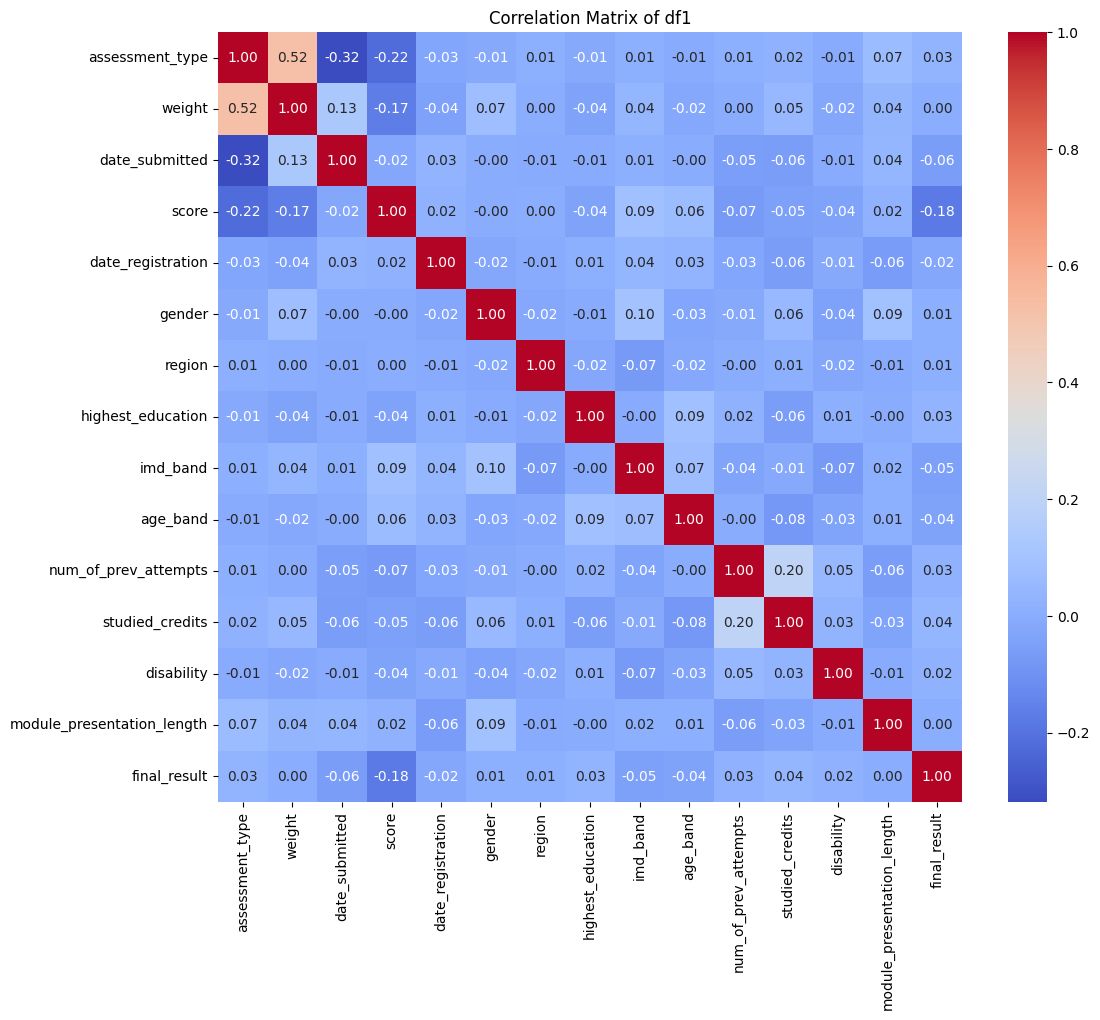

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt


correlation_matrix = df1.corr()


plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of df1")
plt.show()

In [6]:

columns_with_nulls = df1.columns[df1.isnull().any()].tolist()


print(columns_with_nulls)

['date_registration']


In [7]:

correlation_matrix = df1.corr()


date_registration_correlations = correlation_matrix['date_registration']


sorted_correlations = date_registration_correlations.sort_values(ascending=False)


print(sorted_correlations.head(10))  # Print top 10, adjust as needed

date_registration    1.000000
imd_band             0.039478
date_submitted       0.031384
age_band             0.029705
score                0.016325
highest_education    0.014652
region              -0.007192
disability          -0.010334
gender              -0.020563
final_result        -0.020640
Name: date_registration, dtype: float64


In [8]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = df1[['final_result']]
y = df1['date_registration']


X_train = X[y.notnull()]
y_train = y[y.notnull()]


model = LinearRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X)


r2 = r2_score(y_train, model.predict(X_train))


print(f"R-squared: {r2}")

R-squared: 0.00042602713447637


Imputing null values

In [9]:
# Imputing null values in 'date_registration' using predicted values
df1.loc[df1['date_registration'].isnull(), 'date_registration'] = y_pred[df1['date_registration'].isnull()]

In [10]:

null_counts = df1.isnull().sum()


print(null_counts)

assessment_type               0
weight                        0
date_submitted                0
score                         0
date_registration             0
gender                        0
region                        0
highest_education             0
imd_band                      0
age_band                      0
num_of_prev_attempts          0
studied_credits               0
disability                    0
module_presentation_length    0
final_result                  0
dtype: int64


# Feature Selection

In [12]:
from sklearn.model_selection import train_test_split
X = df1.drop('final_result', axis=1)  # Features
y = df1['final_result']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
import statsmodels.api as sm
from itertools import combinations
from multiprocessing import Pool

def evaluate_subset(feature_subset):
    features_to_test = list(feature_subset)
    X_subset = X_train[features_to_test]
    X_subset = sm.add_constant(X_subset)
    model = sm.OLS(y_train, X_subset).fit()
    p_values = model.pvalues[1:]
    return features_to_test, p_values

def feature_selection_combinations_parallel(X, y, alpha=0.05):
    best_features = []
    best_p_values = []

    current_features = []

    for k in range(1, len(X.columns) + 1):
        all_subsets_k = list(combinations(X.columns, k))

        with Pool(processes=4) as pool:
            results = pool.map(evaluate_subset, all_subsets_k)

        for features_to_test, p_values in results:
            if all(p < alpha for p in p_values):
                if set(features_to_test) not in [set(f) for f in best_features]:
                    current_features = features_to_test
                    best_features.append(features_to_test)
                    best_p_values.extend(p_values)

    return best_features[-1] if best_features else [], best_p_values


selected_features, selected_p_values = feature_selection_combinations_parallel(X_train, y_train)
print("Selected Features:", selected_features)
print("Selected Features' p-values:", selected_p_values)

X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

Selected Features: ['weight', 'date_submitted', 'score', 'date_registration', 'gender', 'region', 'highest_education', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'module_presentation_length']
Selected Features' p-values: [1.4071700951302375e-28, 3.309461142807636e-113, 0.0, 2.5577887941027394e-13, 0.0002990020830706565, 1.812392878880793e-29, 5.765751024733919e-68, 2.767681341268758e-45, 7.972108776158453e-24, 2.3990907102645736e-50, 2.976851790748791e-10, 6.059420552984153e-33, 1.697120055532854e-06, 4.9295316783770685e-05, 4.99552291502763e-90, 0.0003870418150237568, 0.0, 1.2528620093982541e-27, 2.3298823292761497e-12, 8.410941188677672e-29, 0.00017347624491732713, 2.274963704126827e-29, 2.93142934242863e-30, 3.0878313098426544e-29, 1.2749408037173816e-68, 3.8178339112796664e-28, 7.488323921911709e-45, 3.9295300043879727e-28, 2.2299278860340122e-23, 2.5089257563848593e-27, 4.234243210380356e-49, 7.889994079110597e-29, 1.6535663292342094e-10, 3.87937847202001

# Model Selection

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


columns_to_drop = ['assessment_type', 'imd_band', 'final_result']
X = df1.drop(columns=columns_to_drop, axis=1)
X = df1.drop('final_result', axis=1)
y = df1['final_result']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier()
}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f'{model_name}: Accuracy = {accuracy:.4f}, Precision = {precision:.4f}, Recall = {recall:.4f}, F1-score = {f1:.4f}')



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression: Accuracy = 0.6139, Precision = 0.5361, Recall = 0.6139, F1-score = 0.4956
Decision Tree: Accuracy = 0.5557, Precision = 0.5639, Recall = 0.5557, F1-score = 0.5595
Random Forest: Accuracy = 0.7168, Precision = 0.7104, Recall = 0.7168, F1-score = 0.6843
Gradient Boosting: Accuracy = 0.6375, Precision = 0.6070, Recall = 0.6375, F1-score = 0.5646


# Hyperparameter Tuning



In [20]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint


param_dist = {
    'n_estimators': randint(100, 300),
    'max_depth': [None, 5, 10],
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 4)
}


random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42
)
random_search.fit(X_train, y_train)


best_model = random_search.best_estimator_
best_accuracy = random_search.best_score_

print(f"Best Hyperparameters: {random_search.best_params_}")
print(f"Best Accuracy: {best_accuracy:.4f}")

Best Hyperparameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 157}
Best Accuracy: 0.6980


# Recommendation system

In [30]:
# 3. Recommendation System
def generate_recommendations(student_features, model):
    predicted_result = model.predict([student_features])[0]
    if predicted_result == 0:  # Fail
        recommendations = ['Explore additional study resources', 'Consult with an academic advisor']
    elif predicted_result == 1:  # Pass
        recommendations = ['Explore advanced courses in your field', 'Participate in extracurricular activities']
    else:  # Distinction (assuming 2)
        recommendations = ['Apply for scholarships or research opportunities', 'Consider graduate studies']
    return recommendations


def get_student_input(df, training_feature_names, le):
    features = {}

    for feature_name in training_feature_names:
        if feature_name in categorical_cols:
            # Get original values and create a mapping
            original_values = df[feature_name].unique()
            value_mapping = {val: i for i, val in enumerate(original_values)} #changed here

            # Display options and get user input
            print(f"Options for {feature_name}:")
            for val, i in value_mapping.items(): #changed here
                print(f"{val}")

            while True:
                # Get user input using original values directly
                selected_value_original = input(f"Enter your choice for {feature_name}: ")
                if selected_value_original in value_mapping:
                    # Get the encoded value using the mapping
                    features[feature_name] = value_mapping[selected_value_original]
                    break
                else:
                    print("Invalid choice. Please enter a valid option.")

        else:  # Numerical feature (same as before)
            while True:  # Indented block here
                try:
                    value = float(input(f"Enter value for {feature_name}: "))
                    features[feature_name] = value
                    break
                except ValueError:
                    print("Invalid input. Please enter a numerical value.")

    student_features_ordered = [features[name] for name in training_feature_names]
    return student_features_ordered


# 4. Main Execution
def main():
    # Create and fit LabelEncoder before calling get_student_input
    le = LabelEncoder()
    for col in categorical_cols:
        le.fit(df[col])  # Fit on original data

    training_feature_names = X_train.columns.tolist()
    student_features = get_student_input(df, training_feature_names, le)  # Pass le
    recommendations = generate_recommendations(student_features, best_model)
    print("Recommendations:")
    for recommendation in recommendations:
        print(f"- {recommendation}")

if __name__ == "__main__":
    main()

Options for assessment_type:
TMA
CMA
Exam
Enter your choice for assessment_type: TMA
Enter value for weight: 10
Enter value for date_submitted: 20
Enter value for score: 60
Enter value for date_registration: 15
Options for gender:
M
F
Enter your choice for gender: M
Options for region:
East Anglian Region
Scotland
South East Region
West Midlands Region
Wales
North Western Region
North Region
South Region
Ireland
South West Region
East Midlands Region
Yorkshire Region
London Region
Enter your choice for region: Scotland
Options for highest_education:
HE Qualification
A Level or Equivalent
Lower Than A Level
Post Graduate Qualification
No Formal quals
Enter your choice for highest_education: No Formal quals
Options for imd_band:
90-100%
20-30%
50-60%
80-90%
30-40%
70-80%
nan
60-70%
40-50%
10-20
0-10%
Enter your choice for imd_band: 50-60%
Options for age_band:
55<=
35-55
0-35
Enter your choice for age_band: 0-35
Enter value for num_of_prev_attempts: 0
Enter value for studied_credits: 256

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
